In [1]:
import sys
PROJECT_ROOT = r"C:\\Dev\\Synthetic-Data-Generation-For-Cardiovascular-Disease-Risk-Prediction\\"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import torch
from classifier import Classifier
%matplotlib inline
plt.rcParams.update({"font.size":16})

c:\Dev\Synthetic-Data-Generation-For-Cardiovascular-Disease-Risk-Prediction\.venv\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
class_names = ['None', 'MI', 'Stroke', 'Syncope']
classifier_metrics = torch.load("models/classifier10/checkpoint.pth", weights_only=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classifier = Classifier(3,7,4)
classifier.load_state_dict(classifier_metrics['model_state_dict'])
classifier.eval()
classifier.to(device)

Classifier(
  (conv_blocks): Sequential(
    (0): ECG_Conv_Block(
      (conv): Conv1d(3, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (batch_norm): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout1d(p=0.2, inplace=False)
      (leaky_relu): LeakyReLU(negative_slope=0.3)
      (max_pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ECG_Conv_Block(
      (conv): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
      (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout1d(p=0.2, inplace=False)
      (leaky_relu): LeakyReLU(negative_slope=0.3)
      (max_pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ECG_Conv_Block(
      (conv): Conv1d(64, 128, kernel_size=(9,), stride=(1,), padding=(4,))
      (batch_norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affi

In [3]:
from torchinfo import summary
summary(classifier)

Layer (type:depth-idx)                   Param #
Classifier                               --
├─Sequential: 1-1                        --
│    └─ECG_Conv_Block: 2-1               --
│    │    └─Conv1d: 3-1                  512
│    │    └─BatchNorm1d: 3-2             64
│    │    └─Dropout1d: 3-3               --
│    │    └─LeakyReLU: 3-4               --
│    │    └─MaxPool1d: 3-5               --
│    └─ECG_Conv_Block: 2-2               --
│    │    └─Conv1d: 3-6                  14,400
│    │    └─BatchNorm1d: 3-7             128
│    │    └─Dropout1d: 3-8               --
│    │    └─LeakyReLU: 3-9               --
│    │    └─MaxPool1d: 3-10              --
│    └─ECG_Conv_Block: 2-3               --
│    │    └─Conv1d: 3-11                 73,856
│    │    └─BatchNorm1d: 3-12            256
│    │    └─Dropout1d: 3-13              --
│    │    └─LeakyReLU: 3-14              --
│    │    └─MaxPool1d: 3-15              --
│    └─ECG_Conv_Block: 2-4               --
│    │    └─Conv

## Fully Synth Dataset Model

In [4]:
class_names = ['None', 'MI', 'Stroke', 'Syncope']
classifier_metrics = torch.load("models/classifier10/checkpoint.pth", weights_only=False)
class_0_history = classifier_metrics['history']
class_0_synth_metrics = classifier_metrics['synth_test']
class_0_real_metrics = classifier_metrics['real_test']

In [5]:
class_0_history[-1]

{'epoch': 30,
 'train_loss': 0.18967854976654053,
 'train_acc_micro': 0.9262499809265137,
 'train_acc_macro': 0.9266172647476196,
 'train_acc_weighted': 0.9262499809265137,
 'train_f1_macro': 0.9263330698013306,
 'train_f1_weighted': 0.9260459542274475,
 'val_loss': 0.15690885484218597,
 'val_acc_micro': 0.9409999847412109,
 'val_acc_macro': 0.94563889503479,
 'val_acc_weighted': 0.9409999847412109,
 'val_f1_macro': 0.9422808885574341,
 'val_f1_weighted': 0.9400728344917297}

In [6]:
class_0_synth_metrics

{'acc_macro': tensor(0.9355),
 'acc_micro': tensor(0.9410),
 'acc_weighted': tensor(0.9410),
 'conf_mat': tensor([[173,  43,   5,   4],
         [  4, 256,   1,   1],
         [  0,   0, 274,   0],
         [  0,   1,   0, 238]]),
 'f1_macro': tensor(0.9371),
 'f1_micro': tensor(0.9410),
 'f1_per_class': tensor([0.8607, 0.9110, 0.9892, 0.9876]),
 'f1_weighted': tensor(0.9394),
 'precision_macro': tensor(0.9472),
 'precision_micro': tensor(0.9410),
 'precision_per_class': tensor([0.9774, 0.8533, 0.9786, 0.9794]),
 'precision_weighted': tensor(0.9394),
 'recall_macro': tensor(0.9355),
 'recall_micro': tensor(0.9410),
 'recall_per_class': tensor([0.7689, 0.9771, 1.0000, 0.9958]),
 'recall_weighted': tensor(0.9394),
 'loss': tensor(0.1570)}

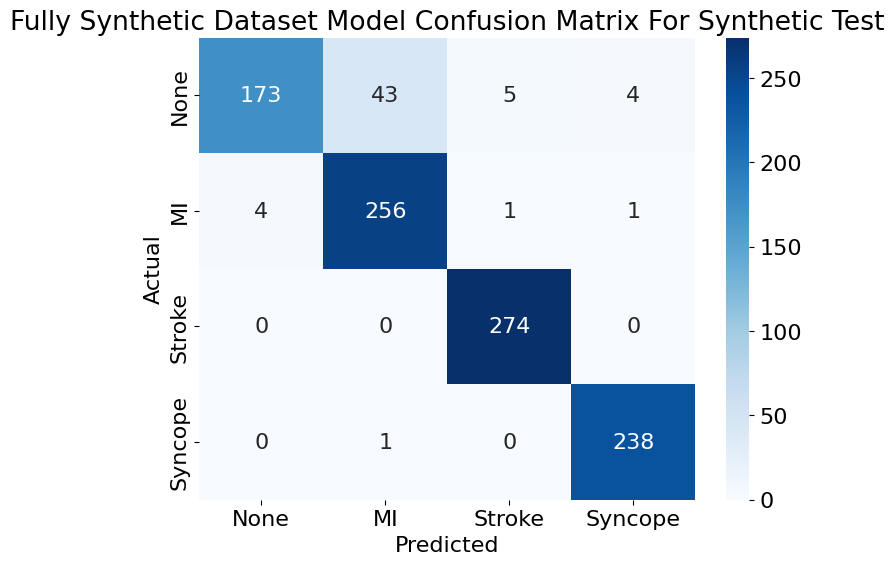

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(class_0_synth_metrics['conf_mat'], annot=True,fmt='d',cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fully Synthetic Dataset Model Confusion Matrix For Synthetic Test")
plt.show()

In [8]:
class_0_real_metrics

{'acc_macro': tensor(0.9607),
 'acc_micro': tensor(0.8623),
 'acc_weighted': tensor(0.8623),
 'conf_mat': tensor([[102,  16,   2,   1],
         [  0,  11,   0,   0],
         [  0,   0,   3,   0],
         [  0,   0,   0,   3]]),
 'f1_macro': tensor(0.7752),
 'f1_micro': tensor(0.8623),
 'f1_per_class': tensor([0.9148, 0.5789, 0.7500, 0.8571]),
 'f1_weighted': tensor(0.8832),
 'precision_macro': tensor(0.6894),
 'precision_micro': tensor(0.8623),
 'precision_per_class': tensor([1.0000, 0.4074, 0.6000, 0.7500]),
 'precision_weighted': tensor(0.8832),
 'recall_macro': tensor(0.9607),
 'recall_micro': tensor(0.8623),
 'recall_per_class': tensor([0.8430, 1.0000, 1.0000, 1.0000]),
 'recall_weighted': tensor(0.8832),
 'loss': tensor(0.4268)}

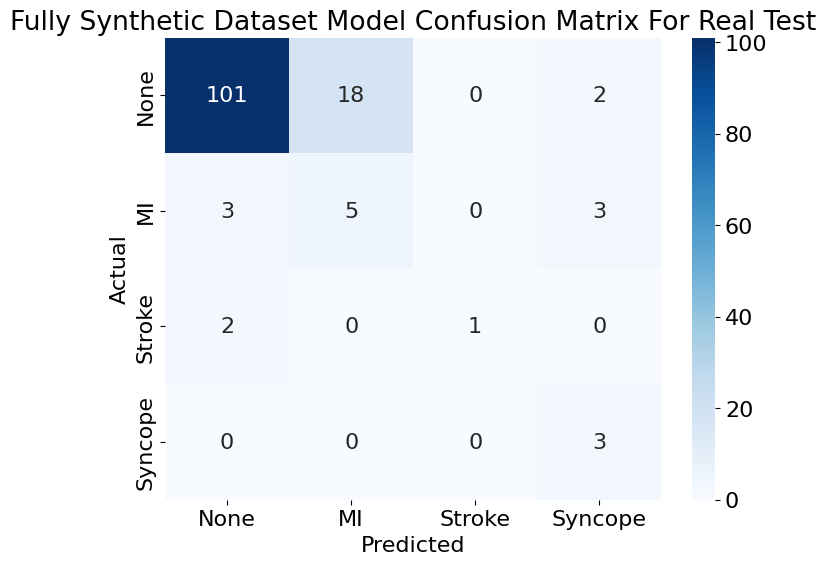

In [81]:
plt.figure(figsize=(8,6))
sns.heatmap(class_0_real_metrics['conf_mat'], annot=True,fmt='d',cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fully Synthetic Dataset Model Confusion Matrix For Real Test")
plt.show()

## Half Real-Synth Dataset Model

In [82]:
classifier_metrics = torch.load("models/classifier1/checkpoint.pth", weights_only=False)
class_1_history = classifier_metrics['history']
class_1_synth_metrics = classifier_metrics['synth_test']
class_1_real_metrics = classifier_metrics['real_test']

In [83]:
class_1_history[-1]

{'epoch': 10,
 'train_loss': 0.36821895837783813,
 'train_acc_micro': 0.8495000004768372,
 'train_acc_macro': 0.8503224849700928,
 'train_acc_weighted': 0.8495000004768372,
 'train_f1_macro': 0.8483361005783081,
 'train_f1_weighted': 0.8476905822753906,
 'val_loss': 0.2653847634792328,
 'val_acc_micro': 0.8840000033378601,
 'val_acc_macro': 0.8919739127159119,
 'val_acc_weighted': 0.8840000033378601,
 'val_f1_macro': 0.883849561214447,
 'val_f1_weighted': 0.8792971968650818}

In [84]:
class_1_synth_metrics

{'acc_macro': tensor(0.8791),
 'acc_micro': tensor(0.8880),
 'acc_weighted': tensor(0.8880),
 'conf_mat': tensor([[138,  59,  17,  11],
         [ 16, 241,   4,   1],
         [  0,   0, 274,   0],
         [  2,   2,   0, 235]]),
 'f1_macro': tensor(0.8773),
 'f1_per_class': tensor([0.7244, 0.8546, 0.9631, 0.9671]),
 'f1_weighted': tensor(0.8819),
 'precision_macro': tensor(0.8907),
 'precision_per_class': tensor([0.8846, 0.7980, 0.9288, 0.9514]),
 'recall_macro': tensor(0.8791),
 'recall_per_class': tensor([0.6133, 0.9198, 1.0000, 0.9833]),
 'loss': tensor(0.2583)}

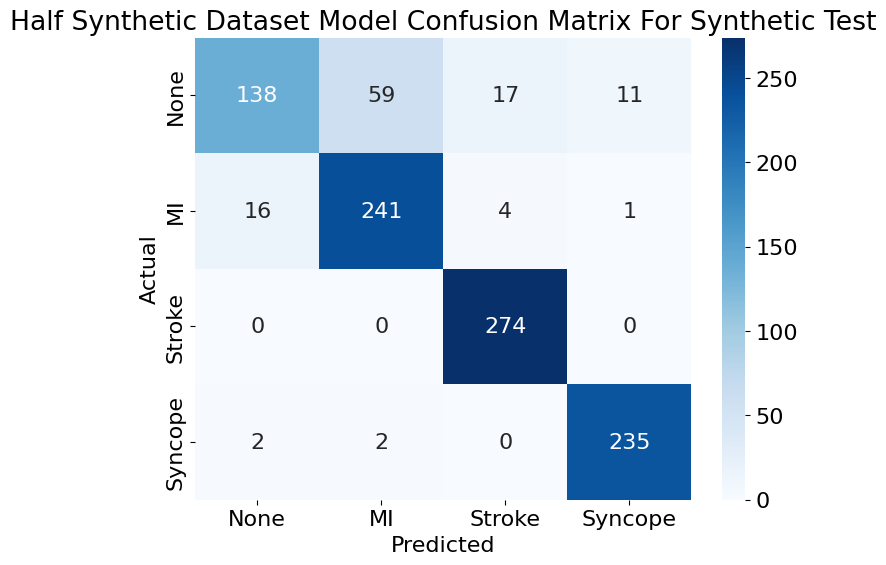

In [85]:
plt.figure(figsize=(8,6))
sns.heatmap(class_1_synth_metrics['conf_mat'], annot=True,fmt='d',cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Half Synthetic Dataset Model Confusion Matrix For Synthetic Test")
plt.show()

In [86]:
class_1_real_metrics

{'acc_macro': tensor(0.9070),
 'acc_micro': tensor(0.7464),
 'acc_weighted': tensor(0.7464),
 'conf_mat': tensor([[87, 31,  3,  0],
         [ 1, 10,  0,  0],
         [ 0,  0,  3,  0],
         [ 0,  0,  0,  3]]),
 'f1_macro': tensor(0.7210),
 'f1_per_class': tensor([0.8325, 0.3846, 0.6667, 1.0000]),
 'f1_weighted': tensor(0.7969),
 'precision_macro': tensor(0.6831),
 'precision_per_class': tensor([0.9886, 0.2439, 0.5000, 1.0000]),
 'recall_macro': tensor(0.9070),
 'recall_per_class': tensor([0.7190, 0.9091, 1.0000, 1.0000]),
 'loss': tensor(0.5181)}

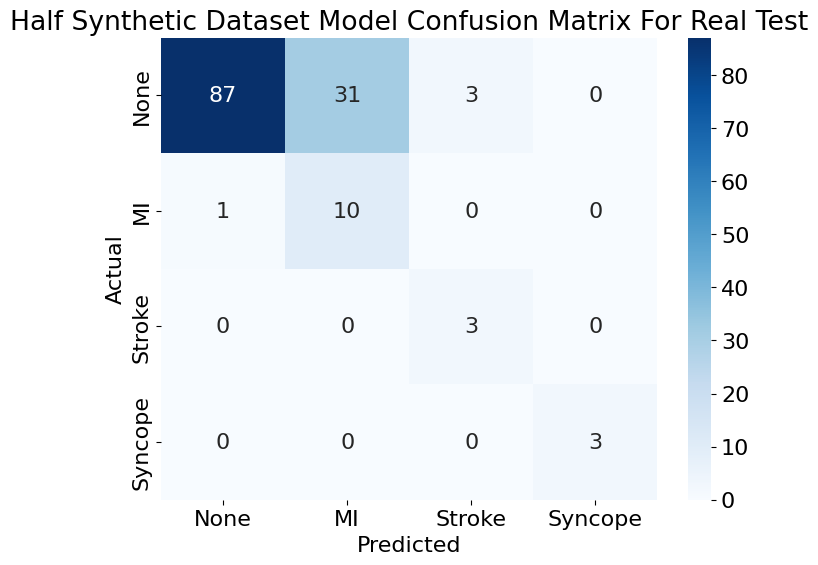

In [87]:
plt.figure(figsize=(8,6))
sns.heatmap(class_1_real_metrics['conf_mat'], annot=True,fmt='d',cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Half Synthetic Dataset Model Confusion Matrix For Real Test")
plt.show()

## Fully Real Dataset Model

In [88]:
classifier_metrics = torch.load("models/classifier2/checkpoint.pth", weights_only=False)
class_2_history = classifier_metrics['history']
class_2_synth_metrics = classifier_metrics['synth_test']
class_2_real_metrics = classifier_metrics['real_test']

In [89]:
class_2_history[-1]

{'epoch': 10,
 'train_loss': 0.21698962152004242,
 'train_acc_micro': 0.9142500162124634,
 'train_acc_macro': 0.914197564125061,
 'train_acc_weighted': 0.9142500162124634,
 'train_f1_macro': 0.9136151075363159,
 'train_f1_weighted': 0.9136885404586792,
 'val_loss': 0.1525040566921234,
 'val_acc_micro': 0.9390000104904175,
 'val_acc_macro': 0.940271258354187,
 'val_acc_weighted': 0.9390000104904175,
 'val_f1_macro': 0.9404066801071167,
 'val_f1_weighted': 0.9381576776504517}

In [90]:
class_2_synth_metrics

{'acc_macro': tensor(0.9516),
 'acc_micro': tensor(0.9530),
 'acc_weighted': tensor(0.9530),
 'conf_mat': tensor([[203,  35,   2,   4],
         [  5, 228,   0,   1],
         [  0,   0, 253,   0],
         [  0,   0,   0, 269]]),
 'f1_macro': tensor(0.9506),
 'f1_per_class': tensor([0.8982, 0.9175, 0.9961, 0.9908]),
 'f1_weighted': tensor(0.9524),
 'precision_macro': tensor(0.9542),
 'precision_per_class': tensor([0.9760, 0.8669, 0.9922, 0.9818]),
 'recall_macro': tensor(0.9516),
 'recall_per_class': tensor([0.8320, 0.9744, 1.0000, 1.0000]),
 'loss': tensor(0.1286)}

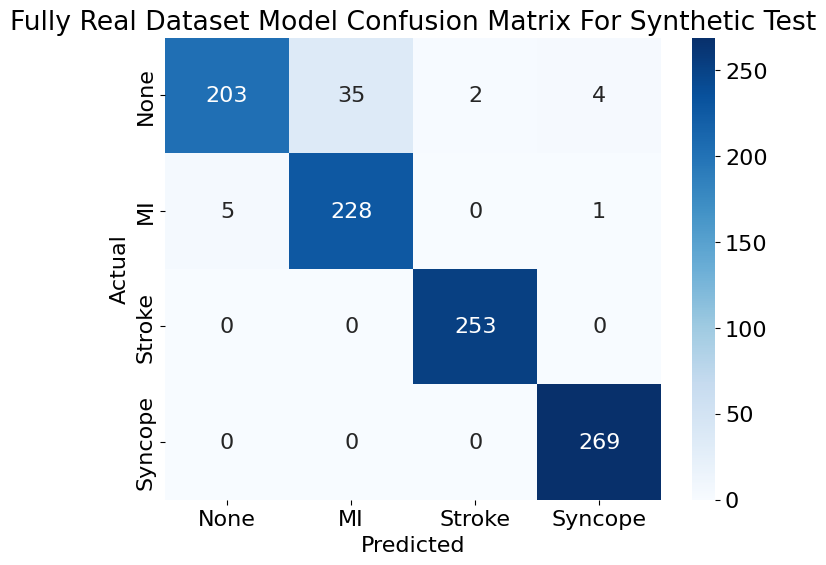

In [91]:
plt.figure(figsize=(8,6))
sns.heatmap(class_2_synth_metrics['conf_mat'], annot=True,fmt='d',cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fully Real Dataset Model Confusion Matrix For Synthetic Test")
plt.show()

In [92]:
class_2_real_metrics

{'acc_macro': tensor(0.9483),
 'acc_micro': tensor(0.8913),
 'acc_weighted': tensor(0.8913),
 'conf_mat': tensor([[107,  12,   1,   1],
         [  1,  10,   0,   0],
         [  0,   0,   3,   0],
         [  0,   0,   0,   3]]),
 'f1_macro': tensor(0.8137),
 'f1_per_class': tensor([0.9345, 0.6061, 0.8571, 0.8571]),
 'f1_weighted': tensor(0.9050),
 'precision_macro': tensor(0.7363),
 'precision_per_class': tensor([0.9907, 0.4545, 0.7500, 0.7500]),
 'recall_macro': tensor(0.9483),
 'recall_per_class': tensor([0.8843, 0.9091, 1.0000, 1.0000]),
 'loss': tensor(0.3067)}

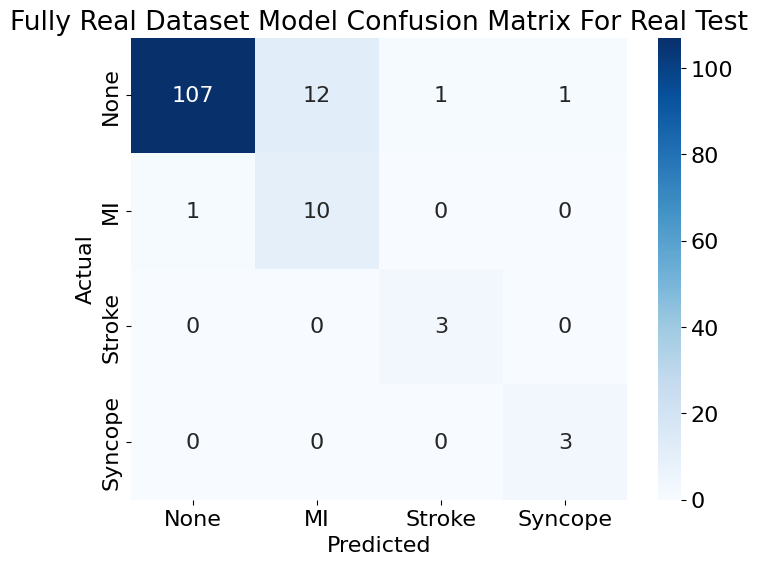

In [93]:
plt.figure(figsize=(8,6))
sns.heatmap(class_2_real_metrics['conf_mat'], annot=True,fmt='d',cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fully Real Dataset Model Confusion Matrix For Real Test")
plt.show()